# CRISP-DM: Predicting `is_fraud` (Part 2)

End-to-end pipeline: SQLite → denormalized features → sklearn → save model for deployment.

**Train once, score many:** After you have `fraud_order_pipeline.joblib`, set `FORCE_FULL_TRAIN = False` in the **imports** cell to skip §4–§6 (slow). Your order/checkout service should load that file only — see `score_fraud_order.py` in this folder.

---

## Installation (run once)

In **Terminal**, **Anaconda Prompt**, or a notebook cell with `!pip`:

```bash
pip install pandas numpy scikit-learn matplotlib seaborn sqlalchemy joblib
```

**Optional — Supabase / Postgres URL from dashboard:**

```bash
pip install supabase psycopg2-binary python-dotenv
```

**Optional — extra tree libraries:**

```bash
pip install xgboost lightgbm
```

Use **Python 3.10+** if possible (matches most course materials).

---

## Notebook outline (CRISP-DM)

1. Business Understanding  
2. Data Understanding  
3. Data Preparation (datetime, interactions `fe_*`, split, preprocess)  
4. Compare models (CV: PR-AUC & ROC-AUC) — **offline only**  
5. Tune champion (Ch. 15)  
6. Feature selection (Ch. 16)  
7. Evaluation  
8. Deployment (`joblib`) + website I/O  
9. **Production manifest** (`fraud_model_manifest.json`) for Railway / Supabase / GitHub

## 1. Business Understanding

**Problem:** Binary classification — predict whether an order is fraudulent (`is_fraud` = 1) or not (0).

**Success criteria (typical for fraud):** Precision/recall, F1, PR-AUC or ROC-AUC — not accuracy alone if classes are imbalanced.

**Stakeholders:** Fraud/risk, operations, customers affected by false positives.

*Edit this cell to match your write-up.*

## 2. Data Understanding — load & denormalize

We load `shop.db`, join `orders` with `customers`, `order_items` (+ `products`), and `shipments` into **one row per order** for ML.

In [ ]:
# --- Imports & database connection ---
# pathlib: cross-platform file paths (works on Windows/macOS/Linux).
# numpy / pandas: tables, vectors, and datetime handling for ML.
# sqlite3: built-in driver to read the course `shop.db` without a separate server.

from pathlib import Path

import json
import numpy as np
import pandas as pd
import sqlite3

# Absolute path to the SQLite file for this assignment (adjust if you move the project).
DB_PATH = Path(r"C:\Users\casey\Documents\OneDrive\IS jr\455\Chapter17Assignment\shop.db")
assert DB_PATH.exists(), f"Missing database: {DB_PATH}"

PROJECT_ROOT = DB_PATH.parent
MODEL_PATH = PROJECT_ROOT / "fraud_order_pipeline.joblib"
MANIFEST_PATH = PROJECT_ROOT / "fraud_model_manifest.json"

# --- Train once, score many (your site / API) ---
# FORCE_FULL_TRAIN = True  → run §4 (model zoo), §5 (tuning), §6 (RFE), then save joblib + manifest.
# FORCE_FULL_TRAIN = False → skip those if MODEL_PATH exists (fast); use the saved pipeline for §7+.
PRIMARY_METRIC = "average_precision"  # PR-AUC for §4–§5; set to "roc_auc" to rank by ROC-AUC instead
CV_FOLDS = 3

FORCE_FULL_TRAIN = True
if not FORCE_FULL_TRAIN and not MODEL_PATH.exists():
    FORCE_FULL_TRAIN = True
    print("No saved pipeline at MODEL_PATH — will run full training (§4–§6).")
elif not FORCE_FULL_TRAIN:
    print("Fast path: will load saved pipeline from", MODEL_PATH.resolve())

# Open a read/write connection. We will run one big SQL query, then close to free the file handle.
conn = sqlite3.connect(DB_PATH)


In [2]:
# --- Denormalized query: one row per order, every table represented ---
# - `o.*` = all columns from `orders` (including `is_fraud`).
# - `customers`: every column with `cust_` prefix (avoids name clashes with `orders`).
# - `shipments`: pre-decision fields only (`ship_promised_days`, carrier, etc.). We omit `actual_days` and
#   `late_delivery` — those are post-fulfillment outcomes, not available at order/checkout scoring time.
# - `basket` subquery: everything from `order_items` joined to `products`, aggregated to order grain
#   (sums, mins/maxs, GROUP_CONCAT of skus/categories/names for inspection — can drop or hash for modeling).
# - `rev` subquery: `product_reviews` for line items where `pr.review_datetime <= o.order_datetime` only
#   (no reviews written after the order — avoids future-information leakage). Text is truncated for EDA.
# Trim or drop wide text columns before production modeling if needed.

DENORMALIZED_SQL = """
SELECT
  o.*,
  c.customer_id AS cust_customer_id,
  c.full_name AS cust_full_name,
  c.email AS cust_email,
  c.gender AS cust_gender,
  c.birthdate AS cust_birthdate,
  c.created_at AS cust_created_at,
  c.city AS cust_city,
  c.state AS cust_state,
  c.zip_code AS cust_zip,
  c.customer_segment AS cust_customer_segment,
  c.loyalty_tier AS cust_loyalty_tier,
  c.is_active AS cust_is_active,
  s.shipment_id AS ship_shipment_id,
  s.ship_datetime AS ship_ship_datetime,
  s.carrier AS ship_carrier,
  s.shipping_method AS ship_shipping_method,
  s.distance_band AS ship_distance_band,
  s.promised_days AS ship_promised_days,
  basket.oi_n_line_rows AS n_lines,
  basket.oi_n_distinct_order_item_ids,
  basket.oi_min_order_item_id,
  basket.oi_max_order_item_id,
  basket.oi_sum_quantity AS total_quantity,
  basket.oi_avg_quantity_per_line,
  basket.oi_min_line_quantity,
  basket.oi_max_line_quantity,
  basket.oi_avg_unit_price,
  basket.oi_min_unit_price,
  basket.oi_max_unit_price,
  basket.oi_sum_line_total AS sum_line_total,
  basket.oi_avg_line_total,
  basket.oi_min_line_total,
  basket.oi_max_line_total,
  basket.oi_n_distinct_products AS n_distinct_products,
  basket.oi_n_distinct_categories AS n_distinct_categories,
  basket.oi_n_distinct_skus,
  basket.oi_sum_qty_times_product_cost,
  basket.oi_sum_qty_times_product_list_price,
  basket.oi_avg_product_list_price,
  basket.oi_min_product_list_price,
  basket.oi_max_product_list_price,
  basket.oi_avg_product_cost,
  basket.oi_min_product_is_active,
  basket.oi_max_product_is_active,
  basket.oi_concat_skus,
  basket.oi_concat_categories,
  basket.oi_concat_product_names,
  rev.rev_n_reviews,
  rev.rev_avg_rating,
  rev.rev_min_rating,
  rev.rev_max_rating,
  rev.rev_min_review_datetime,
  rev.rev_max_review_datetime,
  rev.rev_sum_text_length,
  rev.rev_review_text_concat
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN shipments s ON o.order_id = s.order_id
LEFT JOIN (
  SELECT
    oi.order_id,
    COUNT(*) AS oi_n_line_rows,
    COUNT(DISTINCT oi.order_item_id) AS oi_n_distinct_order_item_ids,
    MIN(oi.order_item_id) AS oi_min_order_item_id,
    MAX(oi.order_item_id) AS oi_max_order_item_id,
    SUM(oi.quantity) AS oi_sum_quantity,
    AVG(oi.quantity) AS oi_avg_quantity_per_line,
    MIN(oi.quantity) AS oi_min_line_quantity,
    MAX(oi.quantity) AS oi_max_line_quantity,
    AVG(oi.unit_price) AS oi_avg_unit_price,
    MIN(oi.unit_price) AS oi_min_unit_price,
    MAX(oi.unit_price) AS oi_max_unit_price,
    SUM(oi.line_total) AS oi_sum_line_total,
    AVG(oi.line_total) AS oi_avg_line_total,
    MIN(oi.line_total) AS oi_min_line_total,
    MAX(oi.line_total) AS oi_max_line_total,
    COUNT(DISTINCT oi.product_id) AS oi_n_distinct_products,
    COUNT(DISTINCT p.category) AS oi_n_distinct_categories,
    COUNT(DISTINCT p.sku) AS oi_n_distinct_skus,
    SUM(oi.quantity * COALESCE(p.cost, 0)) AS oi_sum_qty_times_product_cost,
    SUM(oi.quantity * COALESCE(p.price, 0)) AS oi_sum_qty_times_product_list_price,
    AVG(p.price) AS oi_avg_product_list_price,
    MIN(p.price) AS oi_min_product_list_price,
    MAX(p.price) AS oi_max_product_list_price,
    AVG(p.cost) AS oi_avg_product_cost,
    MIN(p.is_active) AS oi_min_product_is_active,
    MAX(p.is_active) AS oi_max_product_is_active,
    GROUP_CONCAT(DISTINCT p.sku) AS oi_concat_skus,
    GROUP_CONCAT(DISTINCT p.category) AS oi_concat_categories,
    GROUP_CONCAT(DISTINCT p.product_name) AS oi_concat_product_names
  FROM order_items oi
  LEFT JOIN products p ON oi.product_id = p.product_id
  GROUP BY oi.order_id
) basket ON o.order_id = basket.order_id
LEFT JOIN (
  SELECT
    o.order_id,
    COUNT(pr.review_id) AS rev_n_reviews,
    AVG(pr.rating) AS rev_avg_rating,
    MIN(pr.rating) AS rev_min_rating,
    MAX(pr.rating) AS rev_max_rating,
    MIN(pr.review_datetime) AS rev_min_review_datetime,
    MAX(pr.review_datetime) AS rev_max_review_datetime,
    SUM(LENGTH(COALESCE(pr.review_text, ''))) AS rev_sum_text_length,
    SUBSTR(GROUP_CONCAT(COALESCE(pr.review_text, ''), ' | '), 1, 8000) AS rev_review_text_concat
  FROM orders o
  INNER JOIN order_items oi ON o.order_id = oi.order_id
  INNER JOIN product_reviews pr
    ON pr.product_id = oi.product_id
    AND pr.customer_id = o.customer_id
    AND pr.review_datetime <= o.order_datetime
  GROUP BY o.order_id
) rev ON o.order_id = rev.order_id
"""

# Execute the query into a DataFrame, then release the DB connection.
df = pd.read_sql_query(DENORMALIZED_SQL, conn)
conn.close()

# Parse order time as real datetimes; invalid strings become NaT (coerce) so we can detect issues in EDA.
df["order_datetime"] = pd.to_datetime(df["order_datetime"], errors="coerce")

# --- Drop post-order / post-decision columns (not available at checkout / order scoring time) ---
POST_ORDER_DROP_COLUMNS = [
    "risk_score",  # typically derived after review or with label-like information
    "ship_ship_datetime",  # fulfillment timestamp; not known at order placement
    "ship_actual_days",
    "ship_late_delivery",
]
_post_order_present = [c for c in POST_ORDER_DROP_COLUMNS if c in df.columns]
df = df.drop(columns=_post_order_present)
if _post_order_present:
    print("Dropped post-order columns:", _post_order_present)

# Quick sanity check: number of rows/columns and class balance for `is_fraud` (fraud is usually the minority).
df.shape, df["is_fraud"].value_counts()

Dropped post-order columns: ['risk_score', 'ship_ship_datetime']


((5000, 70),
 is_fraud
 0    4682
 1     318
 Name: count, dtype: int64)

In [3]:
# Just the toes of the df so the rest of the file runs quickly.
# df = df.sample(n=100, random_state=42).reset_index(drop=True)

In [4]:
# Peek at the first rows: verify dtypes, column names, and that joins look reasonable.
with pd.option_context('display.max_columns', None):
    display(df.head())

,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,is_fraud,cust_customer_id,cust_full_name,cust_email,cust_gender,cust_birthdate,cust_created_at,cust_city,cust_state,cust_zip,cust_customer_segment,cust_loyalty_tier,cust_is_active,ship_shipment_id,ship_carrier,ship_shipping_method,ship_distance_band,ship_promised_days,n_lines,oi_n_distinct_order_item_ids,oi_min_order_item_id,oi_max_order_item_id,total_quantity,oi_avg_quantity_per_line,oi_min_line_quantity,oi_max_line_quantity,oi_avg_unit_price,oi_min_unit_price,oi_max_unit_price,sum_line_total,oi_avg_line_total,oi_min_line_total,oi_max_line_total,n_distinct_products,n_distinct_categories,oi_n_distinct_skus,oi_sum_qty_times_product_cost,oi_sum_qty_times_product_list_price,oi_avg_product_list_price,oi_min_product_list_price,oi_max_product_list_price,oi_avg_product_cost,oi_min_product_is_active,oi_max_product_is_active,oi_concat_skus,oi_concat_categories,oi_concat_product_names,rev_n_reviews,rev_avg_rating,rev_min_rating,rev_max_rating,rev_min_review_datetime,rev_max_review_datetime,rev_sum_text_length,rev_review_text_concat
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,NaN,662.95,15.44,46.30,724.69,0,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,1,UPS,expedited,regional,3,5,5,1,5,9,1.800000,1,3,69.242,23.16,99.90,662.95,132.590000,28.10,290.52,5,4,5,407.95,662.95,69.242,23.16,99.90,41.120,1,1,"SKU-0015,SKU-0058,SKU-0073,SKU-0028,SKU-0024","Books,Beauty,Home,Apparel","Professional Water Bottle,Lightweight Cookware...",1.0,2.0,2.0,2.0,2025-11-20 20:09:40,2025-11-20 20:09:40,30.0,Disappointed with the quality.
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,0,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,2,FedEx,expedited,local,2,5,5,6,10,7,1.400000,1,3,133.300,47.27,241.51,862.92,172.584000,47.27,294.63,5,3,5,502.81,862.92,133.300,47.27,241.51,79.358,1,1,"SKU-0006,SKU-0013,SKU-0028,SKU-0067,SKU-0001","Automotive,Home,Garden","Professional Flashlight,Classic Wallet,Smart D...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,NaN,796.09,14.04,40.72,850.85,1,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,3,FedEx,expedited,national,4,3,3,11,13,5,1.666667,1,2,140.850,49.01,230.50,796.09,265.363333,49.01,461.00,3,2,3,498.39,796.09,140.850,49.01,230.50,87.200,1,1,"SKU-0013,SKU-0001,SKU-0059","Home,Garden","Classic Wallet,Portable Tool Kit,Advanced Head...",2.0,3.0,3.0,3.0,2025-10-01 06:28:40,2025-11-03 14:16:40,0.0,|
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,WELCOME,137.60,6.99,11.88,156.47,0,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,4,UPS,standard,regional,6,1,1,14,14,1,1.000000,1,1,137.600,137.60,137.60,137.60,137.600000,137.60,137.60,1,1,1,82.66,137.60,137.600,137.60,137.60,82.660,1,1,SKU-0082,Garden,Professional Monitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,NaN,17.07,6.99,1.40,25.46,0,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,5,USPS,standard,regional,6,1,1,15,15,1,1.000000,1,1,17.070,17.07,17.07,17.07,17.070000,17.07,17.07,1,1,1,8.38,17.07,17.070,17.07,17.07,8.380,1,1,SKU-0094,Books,Smart Chair,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.drop(columns=['order_id', 'customer_id', 'cust_customer_id', 'ship_shipment_id', 'oi_concat_skus'], inplace=True, errors = 'ignore')

In [6]:
#`info()` shows dtypes and non-null counts (spot wrong types, e.g. numeric stored as text).
df.info()

#Count missing values per column, worst first — informs imputation strategy in the sklearn pipeline.
df.isna().sum().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 65 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   order_datetime                       5000 non-null   datetime64[us]
 1   billing_zip                          5000 non-null   str           
 2   shipping_zip                         5000 non-null   str           
 3   shipping_state                       5000 non-null   str           
 4   payment_method                       5000 non-null   str           
 5   device_type                          5000 non-null   str           
 6   ip_country                           5000 non-null   str           
 7   promo_used                           5000 non-null   int64         
 8   promo_code                           1261 non-null   str           
 9   order_subtotal                       5000 non-null   float64       
 10  shipping_fee           

rev_review_text_concat     4189
rev_max_rating             4189
rev_sum_text_length        4189
rev_max_review_datetime    4189
rev_min_review_datetime    4189
rev_avg_rating             4189
rev_min_rating             4189
rev_n_reviews              4189
promo_code                 3739
order_datetime                0
billing_zip                   0
shipping_state                0
shipping_zip                  0
payment_method                0
device_type                   0
ip_country                    0
promo_used                    0
cust_birthdate                0
cust_created_at               0
cust_city                     0
dtype: int64

### EDA plots (Ch. 6 & 8)

Add histograms, boxplots, and fraud rate by category. *Extend below.*

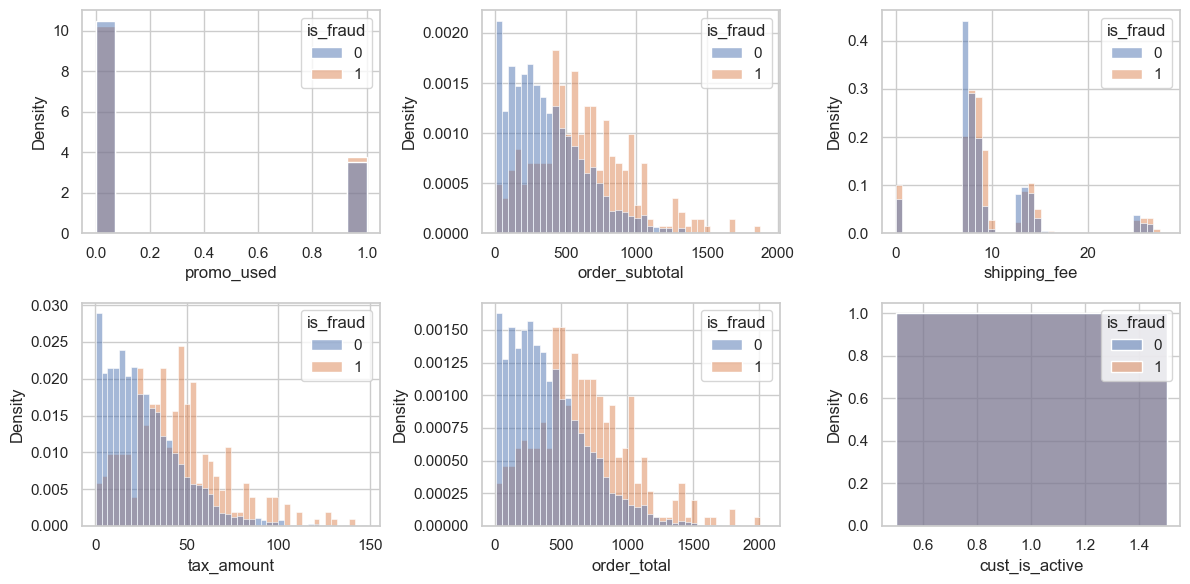

In [7]:
# --- Exploratory plots (Ch. 6 / 8): numeric distributions by fraud label ---
# Overlaid histograms help see whether a feature separates fraud vs non-fraud (shift in density).
# We skip `is_fraud` itself as a plotted x-axis (it's the target).

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Keep only numeric columns from the raw denormalized frame (before engineered time splits).
num_cols = df.select_dtypes(include=[np.number]).columns.drop("is_fraud", errors="ignore")
if len(num_cols) > 0:
    n = min(6, len(num_cols))
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.ravel()
    for i, col in enumerate(num_cols[:6]):
        sns.histplot(
            data=df,
            x=col,
            hue="is_fraud",
            stat="density",
            common_norm=False,  # compare shapes, not forced same area
            ax=axes[i],
        )
    for j in range(n, 6):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

## 3. Data Preparation — features, split, `Pipeline`

1. **Enrich the table** — Decompose `order_datetime` into numeric columns you can store in SQLite/Supabase (`df_ml`) and reuse for ML.  
2. **Interaction & transforms (§3b)** — Add `fe_*` columns (e.g. billing vs shipping ZIP mismatch, money ratios, basket stats).  
3. **Build `X` / `y`** — Drop identifiers and optional leakage (e.g. `risk_score`).  
4. **Train / test split** — Stratified on `is_fraud`.  
5. **Preprocessing `Pipeline`** — Impute + one-hot, then tuning and feature selection before final evaluation.

In [8]:
# --- Feature engineering: split `order_datetime` into parts (year, month, day, weekday, hour, minute) ---
# Tree models and sklearn expect numeric/categorical columns; a single datetime column is harder in pipelines.
# Values come from the order timestamp only (no leakage) if that timestamp is known at prediction time.
# You can persist `df_ml` with `to_sql` to SQLite/Supabase as your feature table.

df_ml = df.copy()
dt = pd.to_datetime(df_ml["order_datetime"], errors="coerce")

# --- Core parts: year, month, day of month, day of week, hour, minute ---
df_ml["order_year"] = dt.dt.year
df_ml["order_month"] = dt.dt.month
df_ml["order_day_of_month"] = dt.dt.day
df_ml["order_day_of_week"] = dt.dt.dayofweek  # Monday=0 … Sunday=6 (pandas / NumPy convention)
df_ml["order_hour"] = dt.dt.hour
df_ml["order_minute"] = dt.dt.minute

# --- Optional extras for EDA / modeling (drop if you want only the six columns above) ---
df_ml["order_dayofyear"] = dt.dt.dayofyear
df_ml["order_is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)

# Remove raw datetime so only engineered numeric parts go into X (avoids mixed dtype issues).
df_ml = df_ml.drop(columns=["order_datetime"])

with pd.option_context('display.max_columns', None):
    display(df_ml.head())

,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,is_fraud,cust_full_name,cust_email,cust_gender,cust_birthdate,cust_created_at,cust_city,cust_state,cust_zip,cust_customer_segment,cust_loyalty_tier,cust_is_active,ship_carrier,ship_shipping_method,ship_distance_band,ship_promised_days,n_lines,oi_n_distinct_order_item_ids,oi_min_order_item_id,oi_max_order_item_id,total_quantity,oi_avg_quantity_per_line,oi_min_line_quantity,oi_max_line_quantity,oi_avg_unit_price,oi_min_unit_price,oi_max_unit_price,sum_line_total,oi_avg_line_total,oi_min_line_total,oi_max_line_total,n_distinct_products,n_distinct_categories,oi_n_distinct_skus,oi_sum_qty_times_product_cost,oi_sum_qty_times_product_list_price,oi_avg_product_list_price,oi_min_product_list_price,oi_max_product_list_price,oi_avg_product_cost,oi_min_product_is_active,oi_max_product_is_active,oi_concat_categories,oi_concat_product_names,rev_n_reviews,rev_avg_rating,rev_min_rating,rev_max_rating,rev_min_review_datetime,rev_max_review_datetime,rev_sum_text_length,rev_review_text_concat,order_year,order_month,order_day_of_month,order_day_of_week,order_hour,order_minute,order_dayofyear,order_is_weekend
0,28289,28289,CO,card,mobile,US,0,NaN,662.95,15.44,46.30,724.69,0,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,UPS,expedited,regional,3,5,5,1,5,9,1.800000,1,3,69.242,23.16,99.90,662.95,132.590000,28.10,290.52,5,4,5,407.95,662.95,69.242,23.16,99.90,41.120,1,1,"Books,Beauty,Home,Apparel","Professional Water Bottle,Lightweight Cookware...",1.0,2.0,2.0,2.0,2025-11-20 20:09:40,2025-11-20 20:09:40,30.0,Disappointed with the quality.,2025,11,29,5,0,51,333,1
1,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,0,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,FedEx,expedited,local,2,5,5,6,10,7,1.400000,1,3,133.300,47.27,241.51,862.92,172.584000,47.27,294.63,5,3,5,502.81,862.92,133.300,47.27,241.51,79.358,1,1,"Automotive,Home,Garden","Professional Flashlight,Classic Wallet,Smart D...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,9,1,0,10,25,244,0
2,28289,28289,CO,card,mobile,US,0,NaN,796.09,14.04,40.72,850.85,1,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,FedEx,expedited,national,4,3,3,11,13,5,1.666667,1,2,140.850,49.01,230.50,796.09,265.363333,49.01,461.00,3,2,3,498.39,796.09,140.850,49.01,230.50,87.200,1,1,"Home,Garden","Classic Wallet,Portable Tool Kit,Advanced Head...",2.0,3.0,3.0,3.0,2025-10-01 06:28:40,2025-11-03 14:16:40,0.0,|,2025,12,15,0,7,24,349,0
3,28289,28289,CO,bank,mobile,US,1,WELCOME,137.60,6.99,11.88,156.47,0,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,UPS,standard,regional,6,1,1,14,14,1,1.000000,1,1,137.600,137.60,137.60,137.60,137.600000,137.60,137.60,1,1,1,82.66,137.60,137.600,137.60,137.60,82.660,1,1,Garden,Professional Monitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,6,3,18,21,310,0
4,28289,28289,CO,card,mobile,CA,0,NaN,17.07,6.99,1.40,25.46,0,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,USPS,standard,regional,6,1,1,15,15,1,1.000000,1,1,17.070,17.07,17.07,17.07,17.070000,17.07,17.07,1,1,1,8.38,17.07,17.070,17.07,17.07,8.380,1,1,Books,Smart Chair,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,30,6,5,34,334,1


### 3b. Interaction & transformation features (fraud-oriented)

These columns are **derived from fields you already have** in `df_ml`. They encode common fraud hypotheses (e.g. billing vs shipping mismatch, odd totals vs subtotals, basket structure). Names start with **`fe_`** (*feature engineering*) so you can find or drop them easily.

**Notes:** Ratios use safe division (avoid divide-by-zero). `log1p` helps skewed dollar amounts. Revisit each feature for **leakage** (anything not knowable at checkout should be removed for production scoring).

In [9]:
# --- Interaction & transformation layer (appended to `df_ml`) ---
# All new columns are prefixed with `fe_` for clarity. Run this after datetime features, before X / y.

import numpy as np


def _safe_div(numer, denom, fill_value=np.nan):
    """Divide two series; avoid inf when denom is 0; missing stays NaN (imputer handles later)."""
    numer = pd.to_numeric(numer, errors="coerce")
    denom = pd.to_numeric(denom, errors="coerce").replace(0, np.nan)
    out = numer / denom
    if fill_value is not None and not np.isnan(fill_value):
        return out.fillna(fill_value)
    return out


# --- Address / identity consistency (fraud often uses different bill vs ship) ---
# Compare ZIPs as strings so leading zeros and formatting are handled consistently.
if {"billing_zip", "shipping_zip"}.issubset(df_ml.columns):
    _bz = df_ml["billing_zip"].fillna("").astype(str).str.strip()
    _sz = df_ml["shipping_zip"].fillna("").astype(str).str.strip()
    # 1 = billing and shipping ZIP differ (includes cases where one side is blank vs the other).
    df_ml["fe_addr_billing_shipping_zip_mismatch"] = (_bz != _sz).astype(int)

# Registered customer state vs order ship-to state (gift / reship / stolen address patterns).
if {"shipping_state", "cust_state"}.issubset(df_ml.columns):
    df_ml["fe_addr_ship_state_neq_cust_state"] = (
        df_ml["shipping_state"].fillna("").astype(str).str.upper().str.strip()
        != df_ml["cust_state"].fillna("").astype(str).str.upper().str.strip()
    ).astype(int)

# --- Monetary ratios & transforms (unusual tax / fee / total structure) ---
if {"order_total", "order_subtotal"}.issubset(df_ml.columns):
    # Near 1.0 normally; large deviation can flag discounts, fees, or data issues.
    df_ml["fe_money_total_over_subtotal"] = _safe_div(df_ml["order_total"], df_ml["order_subtotal"])

if {"tax_amount", "order_subtotal"}.issubset(df_ml.columns):
    df_ml["fe_money_tax_proxy_of_subtotal"] = _safe_div(df_ml["tax_amount"], df_ml["order_subtotal"])

if {"shipping_fee", "order_total"}.issubset(df_ml.columns):
    df_ml["fe_money_shipping_fee_share_of_total"] = _safe_div(df_ml["shipping_fee"], df_ml["order_total"])

if "order_total" in df_ml.columns:
    # Log stabilizes heavy-tailed spend; trees still benefit from monotonic transform.
    df_ml["fe_log1p_order_total"] = np.log1p(df_ml["order_total"].clip(lower=0))

# --- Basket structure (bots sometimes buy many small lines or odd qty patterns) ---
if {"sum_line_total", "n_lines"}.issubset(df_ml.columns):
    df_ml["fe_basket_avg_line_value"] = _safe_div(df_ml["sum_line_total"], df_ml["n_lines"].clip(lower=1))

if {"total_quantity", "n_lines"}.issubset(df_ml.columns):
    df_ml["fe_basket_units_per_line"] = _safe_div(df_ml["total_quantity"], df_ml["n_lines"].clip(lower=1))

# Explicit interaction: promo flag × basket size (promo abuse patterns).
if {"promo_used", "n_lines"}.issubset(df_ml.columns):
    df_ml["fe_interact_promo_used_x_n_lines"] = (
        pd.to_numeric(df_ml["promo_used"], errors="coerce").fillna(0)
        * pd.to_numeric(df_ml["n_lines"], errors="coerce").fillna(0)
    )

# (Omit `fe_ship_actual_minus_promised_days`: it needs post-delivery `actual_days`, not available at
# order time — same reason `ship_actual_days` / `ship_late_delivery` are excluded from the SQL.)

# Quick peek at new columns only
_fe_cols = [c for c in df_ml.columns if c.startswith("fe_")]
print("Added", len(_fe_cols), "engineered columns:", _fe_cols)
df_ml[_fe_cols].head()

Added 9 engineered columns: ['fe_addr_billing_shipping_zip_mismatch', 'fe_addr_ship_state_neq_cust_state', 'fe_money_total_over_subtotal', 'fe_money_tax_proxy_of_subtotal', 'fe_money_shipping_fee_share_of_total', 'fe_log1p_order_total', 'fe_basket_avg_line_value', 'fe_basket_units_per_line', 'fe_interact_promo_used_x_n_lines']


,fe_addr_billing_shipping_zip_mismatch,fe_addr_ship_state_neq_cust_state,fe_money_total_over_subtotal,fe_money_tax_proxy_of_subtotal,fe_money_shipping_fee_share_of_total,fe_log1p_order_total,fe_basket_avg_line_value,fe_basket_units_per_line,fe_interact_promo_used_x_n_lines
0,0,0,1.093129,0.069839,0.021306,6.587123,132.590000,1.800000,0
1,1,1,1.094273,0.077191,0.015610,6.851471,172.584000,1.400000,5
2,0,0,1.068786,0.051150,0.016501,6.747410,265.363333,1.666667,0
3,0,0,1.137137,0.086337,0.044673,5.059235,137.600000,1.000000,1
4,0,0,1.491506,0.082015,0.274548,3.275634,17.070000,1.000000,0


In [10]:
# --- Supervised learning matrices: features X and target y ---
# `order_id` is an identifier, not a causal input (high cardinality; can let the model memorize orders).
# `is_fraud` is the label — it must never appear inside X (would be perfect leakage).

# Post-outcome / post-order fields — not available at order time. Same names are removed right after
# `read_sql_query` in `POST_ORDER_DROP_COLUMNS`; kept here too so X stays correct if cells run out of order.
FEATURE_DROPS = [
    "order_id",
    "is_fraud",
    "risk_score",
    "ship_ship_datetime",
    "ship_actual_days",
    "ship_late_delivery",
    "fe_ship_actual_minus_promised_days",
]

X = df_ml.drop(columns=[c for c in FEATURE_DROPS if c in df_ml.columns])
y = df_ml["is_fraud"].astype(int)  # 0 = legitimate, 1 = fraud (binary classification)

# sklearn ColumnTransformer needs explicit lists: which columns are numeric vs categorical.
# Strings/objects/categories → one-hot encoding; integers/floats → numeric branch (impute + pass through to trees).
cat_cols = X.select_dtypes(include=["str", "object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Tuple shows (number of categorical inputs, number of numeric inputs); last part previews column names.
len(cat_cols), len(num_cols), X.columns.tolist()[:12]

(25,
 55,
 ['billing_zip',
  'shipping_zip',
  'shipping_state',
  'payment_method',
  'device_type',
  'ip_country',
  'promo_used',
  'promo_code',
  'order_subtotal',
  'shipping_fee',
  'tax_amount',
  'order_total'])

In [11]:
# --- Baseline pipeline: preprocess + HistGradientBoostingClassifier ---
# ColumnTransformer: apply different steps to numeric vs categorical columns in one object.
# Pipeline: chains steps so CV/tuning and deployment refit everything in order (no train/test skew).

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

# Hold out 20% for final evaluation only. stratify=y keeps fraud rate similar in train vs test
# (important when fraud is rare). random_state makes splits reproducible in reports.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Numeric branch: median imputation is robust to outliers; good default for tree models before one-hot mix.
numeric_pipe = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

# Categorical branch: fill missing with mode, then expand each category level into 0/1 columns.
# handle_unknown="ignore" lets production score new category levels without crashing.
# sparse_output=False keeps dense arrays (simpler with HistGradientBoosting in sklearn).
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Combine branches; remainder="drop" is default (columns not listed are dropped — we listed all).
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

# Histogram-based gradient boosting: strong default for heterogeneous tabular data + large feature space after OHE.
model = HistGradientBoostingClassifier(random_state=42)

baseline_pipeline = Pipeline(
    steps=[("preprocess", preprocess), ("model", model)]
)

# Do not fit yet — §4 runs cross-validation across models on `X_train` first (unbiased model pick).
# After the champion is tuned (§5), we fit the final stacked pipeline on `X_train`.
# baseline_pipeline = preprocess + HGB; kept as a convenient default if you skip §4.

## 4. Compare models (CV with PR-AUC & ROC-AUC)

**Offline only** — run this section in the notebook when choosing a model. **Do not** re-run model comparison on Railway in production; deploy only the saved `joblib` + manifest from this notebook.

- **PR-AUC** (`average_precision` in sklearn) is usually preferred for **rare fraud** (focuses on ranking positives).
- **ROC-AUC** (`roc_auc`) summarizes overall rank across both classes.

The table below reports **mean ± std** on training folds (`cv=3`). The **champion** is picked by **PR-AUC** (change `PRIMARY_METRIC` in code if you want ROC-AUC instead).

In [12]:
if FORCE_FULL_TRAIN:
    # --- Multi-model comparison (same preprocessing for every candidate) ---
    from sklearn.base import clone
    from sklearn.model_selection import cross_validate
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import (
        RandomForestClassifier,
        HistGradientBoostingClassifier,
        GradientBoostingClassifier,
    )

    # Same ColumnTransformer `preprocess` as above (still unfitted until a pipeline .fit() runs).
    candidate_estimators = [
        (
            "log_reg",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
        (
            "hist_gboost",
            HistGradientBoostingClassifier(random_state=42),
        ),
        (
            "grad_boost",
            GradientBoostingClassifier(random_state=42),
        ),
    ]

    try:
        from xgboost import XGBClassifier

        candidate_estimators.append(
            (
                "xgboost",
                XGBClassifier(
                    random_state=42,
                    n_estimators=200,
                    max_depth=6,
                    eval_metric="logloss",
                    n_jobs=-1,
                ),
            )
        )
    except ImportError:
        print("xgboost not installed; skipping (pip install xgboost).")

    cv_rows = []
    for name, est in candidate_estimators:
        pipe = Pipeline([("preprocess", clone(preprocess)), ("model", est)])
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=CV_FOLDS,
            scoring=["average_precision", "roc_auc"],
            n_jobs=-1,
        )
        cv_rows.append(
            {
                "model": name,
                "pr_auc_mean": scores["test_average_precision"].mean(),
                "pr_auc_std": scores["test_average_precision"].std(),
                "roc_auc_mean": scores["test_roc_auc"].mean(),
                "roc_auc_std": scores["test_roc_auc"].std(),
            }
        )

    _sort_col = "pr_auc_mean" if PRIMARY_METRIC == "average_precision" else "roc_auc_mean"
    model_cv_df = (
        pd.DataFrame(cv_rows)
        .sort_values(_sort_col, ascending=False)
        .reset_index(drop=True)
    )

    display(model_cv_df)

    winner_key = model_cv_df.loc[0, "model"]
    winner_est = dict(candidate_estimators)[winner_key]
    winner_pipeline = Pipeline(
        [("preprocess", clone(preprocess)), ("model", clone(winner_est))]
    )

    print("\nChampion (by", PRIMARY_METRIC, "):", winner_key)
    print("Use `winner_pipeline` + RandomizedSearchCV in the next section.")
else:
    print("Skipping §4 (CV model comparison) — using artifacts from the last full train.")
    if MANIFEST_PATH.exists():
        with open(MANIFEST_PATH, encoding="utf-8") as f:
            _manifest_snapshot = json.load(f)
        winner_key = _manifest_snapshot.get("model_selection", {}).get("cv_winner_key", "unknown")
        _rows = _manifest_snapshot.get("model_selection", {}).get("cross_validation_results", [])
        model_cv_df = pd.DataFrame(_rows) if _rows else pd.DataFrame()
        if not model_cv_df.empty:
            display(model_cv_df)
    else:
        winner_key = "unknown"
        model_cv_df = pd.DataFrame()
        print("(No manifest yet — set FORCE_FULL_TRAIN = True and run §4–§9 once.)")
    winner_pipeline = None


,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
0,log_reg,0.151821,0.021724,0.733474,0.022660
1,grad_boost,0.149071,0.032377,0.743162,0.027233
2,random_forest,0.135150,0.011054,0.712676,0.023224
3,hist_gboost,0.123294,0.005247,0.699138,0.017046
4,xgboost,0.114046,0.006260,0.672411,0.017358



Champion (by average_precision ): log_reg
Use `winner_pipeline` + RandomizedSearchCV in the next section.


## 5. Champion model & hyperparameter tuning

**Champion** = best row from **§4** (`winner_key`, `winner_pipeline`). The next cell runs `RandomizedSearchCV` **only on that estimator** (not the whole zoo again). **Scoring** matches `PRIMARY_METRIC` (PR-AUC by default). Then **§6** feature selection and **§7** test evaluation.

### 5a. Hyperparameter tuning (Ch. 15)

`RandomizedSearchCV` searches **only the champion model’s** hyperparameters. **Scoring:** same as `PRIMARY_METRIC` from §4 (`average_precision` = PR-AUC, or `roc_auc`). Reduce `n_iter` if runtime is long.

In [13]:
if FORCE_FULL_TRAIN:
    # --- Hyperparameter tuning (Ch. 15): RandomizedSearchCV on the §4 champion only ---
    from sklearn.base import clone
    from sklearn.model_selection import RandomizedSearchCV
    import numpy as np

    # Search space depends on which model won in §4
    PARAM_GRIDS = {
        "hist_gboost": {
            "model__learning_rate": [0.02, 0.05, 0.08, 0.1, 0.15, 0.2],
            "model__max_depth": [None, 8, 16, 24],
            "model__max_leaf_nodes": [31, 63, 127],
            "model__min_samples_leaf": [1, 5, 15, 20],
        },
        "grad_boost": {
            "model__learning_rate": [0.02, 0.05, 0.1, 0.15],
            "model__max_depth": [2, 3, 5, 7],
            "model__n_estimators": [100, 200],
        },
        "random_forest": {
            "model__n_estimators": [100, 200, 400],
            "model__max_depth": [None, 12, 24, 40],
            "model__min_samples_leaf": [1, 2, 5],
        },
        "log_reg": {
            "model__C": np.logspace(-3, 2, 12),
            "model__solver": ["lbfgs", "saga"],
        },
        "xgboost": {
            "model__max_depth": [3, 5, 7, 9],
            "model__learning_rate": [0.03, 0.06, 0.1, 0.15],
            "model__n_estimators": [100, 200, 400],
            "model__min_child_weight": [1, 3, 5],
        },
    }

    param_dist = PARAM_GRIDS.get(winner_key, PARAM_GRIDS["hist_gboost"])
    if winner_key not in PARAM_GRIDS:
        print(f"No custom grid for {winner_key}; using HistGradientBoosting grid.")

    search = RandomizedSearchCV(
        clone(winner_pipeline),
        param_distributions=param_dist,
        n_iter=16,
        scoring=PRIMARY_METRIC,
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)
    tuned_pipeline = search.best_estimator_

    print("Champion:", winner_key)
    print("Best params:", search.best_params_)
    print("Best CV score (" + PRIMARY_METRIC + "):", round(search.best_score_, 4))
else:
    print("Skipping §5 (RandomizedSearchCV).")
    search = None
    tuned_pipeline = None


Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\casey\Documents\OneDrive\IS jr\455\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Champion: log_reg
Best params: {'model__solver': 'saga', 'model__C': np.float64(0.001)}
Best CV score (average_precision): 0.1637


c:\Users\casey\Documents\OneDrive\IS jr\455\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 6. Feature selection (Ch. 16)

**What we use:** **Recursive Feature Elimination (`RFE`)** — greedy backward elimination on the *preprocessed* (one-hot) matrix: a **Random Forest** scores importances, then the weakest chunk of features is removed and the process repeats until a target number of transformed columns remains. The **final predictor** is still **HistGradientBoosting** with the tuned settings from §5 — RFE only prunes inputs before the booster.

RFE refits many times, so it is **slower** than one-shot filters. **Faster alternative:** `SelectFromModel` (median threshold on the same RF importances) — swap it in the code cell if runtime is an issue. **Other options:** `SequentialFeatureSelector(direction="backward")`, or L1-based selection.

In [14]:
# --- Feature selection (Ch. 16): greedy backward elimination (RFE) before the booster ---
# Order: raw X -> ColumnTransformer -> dense design matrix -> RFE(RandomForest) -> HistGradientBoosting.

if FORCE_FULL_TRAIN:
    import numpy as np
    from sklearn.pipeline import Pipeline
    from sklearn.base import clone
    from sklearn.feature_selection import RFE
    from sklearn.ensemble import RandomForestClassifier

    # Discover one-hot width once (no model leakage: preprocess only on train).
    _pre = clone(tuned_pipeline.named_steps["preprocess"])
    Xt = _pre.fit_transform(X_train, y_train)
    n_in = Xt.shape[1]
    _feature_names = np.asarray(_pre.get_feature_names_out(), dtype=object)

    _n_keep = int(min(n_in - 1, max(1, min(200, max(40, n_in // 50)))))
    _rfe_step = int(max(1, min(2000, max(50, (n_in - _n_keep) // 25))))

    rfe_selector = RFE(
        estimator=RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),
        n_features_to_select=_n_keep,
        step=_rfe_step,
        verbose=1,
    )

    final_pipeline = Pipeline(
        steps=[
            ("preprocess", clone(tuned_pipeline.named_steps["preprocess"])),
            ("select", rfe_selector),
            ("model", clone(tuned_pipeline.named_steps["model"])),
        ]
    )
    final_pipeline.fit(X_train, y_train)

    mask = final_pipeline.named_steps["select"].get_support()
    print("Retained transformed features:", int(mask.sum()), "/", len(mask), "| n_features_to_select=", _n_keep, "step=", _rfe_step)

    _sel_names = _feature_names[mask]
    print("Selected transformed feature names (first 40):", _sel_names[:40].tolist())
    print("... total selected:", len(_sel_names))
else:
    import joblib

    final_pipeline = joblib.load(MODEL_PATH)
    print("Loaded trained pipeline (preprocess + feature selection + model):", MODEL_PATH.resolve())


Fitting estimator with 7576 features.
Fitting estimator with 7279 features.
Fitting estimator with 6982 features.
Fitting estimator with 6685 features.
Fitting estimator with 6388 features.
Fitting estimator with 6091 features.
Fitting estimator with 5794 features.
Fitting estimator with 5497 features.
Fitting estimator with 5200 features.
Fitting estimator with 4903 features.
Fitting estimator with 4606 features.
Fitting estimator with 4309 features.
Fitting estimator with 4012 features.
Fitting estimator with 3715 features.
Fitting estimator with 3418 features.
Fitting estimator with 3121 features.
Fitting estimator with 2824 features.
Fitting estimator with 2527 features.
Fitting estimator with 2230 features.
Fitting estimator with 1933 features.
Fitting estimator with 1636 features.
Fitting estimator with 1339 features.
Fitting estimator with 1042 features.
Fitting estimator with 745 features.
Fitting estimator with 448 features.


c:\Users\casey\Documents\OneDrive\IS jr\455\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Retained transformed features: 151 / 7576 | n_features_to_select= 151 step= 297
Selected transformed feature names (first 40): ['num__promo_used', 'num__order_subtotal', 'num__shipping_fee', 'num__tax_amount', 'num__order_total', 'num__ship_promised_days', 'num__n_lines', 'num__oi_n_distinct_order_item_ids', 'num__oi_min_order_item_id', 'num__oi_max_order_item_id', 'num__total_quantity', 'num__oi_avg_quantity_per_line', 'num__oi_min_line_quantity', 'num__oi_max_line_quantity', 'num__oi_avg_unit_price', 'num__oi_min_unit_price', 'num__oi_max_unit_price', 'num__sum_line_total', 'num__oi_avg_line_total', 'num__oi_min_line_total', 'num__oi_max_line_total', 'num__n_distinct_products', 'num__n_distinct_categories', 'num__oi_n_distinct_skus', 'num__oi_sum_qty_times_product_cost', 'num__oi_sum_qty_times_product_list_price', 'num__oi_avg_product_list_price', 'num__oi_min_product_list_price', 'num__oi_max_product_list_price', 'num__oi_avg_product_cost', 'num__rev_avg_rating', 'num__rev_min_ratin

c:\Users\casey\Documents\OneDrive\IS jr\455\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 7. Evaluation

Report metrics on the **held-out test set** using `final_pipeline` (tuned + feature selection). Run **once** here for the grade; do not tune on `X_test`.

In [15]:
# --- Evaluation on the held-out test set (run once) ---
# `predict`: hard class labels at default 0.5 threshold.
# `predict_proba[:, 1]`: probability of fraud (class 1) — use for threshold tuning / PR curves.

from sklearn.metrics import classification_report, roc_auc_score

y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Precision/recall/F1 per class; accuracy can mislead under imbalance — interpret fraud (1) carefully.
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC: ranking quality across thresholds; pair with PR-AUC if fraud is very rare.
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0     0.9674    0.6966    0.8099       936
           1     0.1288    0.6562    0.2154        64

    accuracy                         0.6940      1000
   macro avg     0.5481    0.6764    0.5127      1000
weighted avg     0.9137    0.6940    0.7719      1000

ROC-AUC: 0.7216045673076923


## 8. Deployment — save model & website integration

### What you persist

- **One file** (e.g. `fraud_pipeline.joblib`) containing **`final_pipeline`**: preprocessing + feature selection + model.  
- Your app loads it with `joblib.load` and calls **`predict`** / **`predict_proba`** on a DataFrame with **the same raw columns as `X`** (including `order_year`, `order_month`, `order_day_of_month`, `order_day_of_week`, `order_hour`, `order_minute`, optional `order_dayofyear` / `order_is_weekend` — not `order_datetime`).

### What the website / API receives **from** the pipeline

After a checkout or review request, your backend builds a **feature dict or row** matching training columns, wraps it in `pd.DataFrame([row])`, then:

| Output | Type | Meaning |
|--------|------|--------|
| `predict()` | `array` of `{0,1}` | Predicted class: **0 = not fraud**, **1 = fraud** |
| `predict_proba()` | `array` shape `(n_samples, 2)` | `[P(not fraud), P(fraud)]` for class order `classes_` |

Example **JSON your API can return** to the frontend:

```json
{
  "is_fraud": false,
  "fraud_probability": 0.08,
  "not_fraud_probability": 0.92,
  "model_version": "fraud_pipeline.joblib"
}
```

Map `fraud_probability` from `predict_proba[:, 1]` (index of class `1` in `pipeline.named_steps['model'].classes_`).

### What the website must **send** (input contract)

Same features as training `X` (all columns from `df_ml` except `order_id` / `is_fraud`), with calendar fields matching how you built them here. **Do not** send `is_fraud` for scoring.

---

Optional: store **Supabase** Postgres URL in `.env` and load features from a table; scoring still runs the same `joblib` pipeline in Python.

In [16]:
# --- Serialize the full fitted pipeline for deployment (Ch. 17) ---
# joblib bundles preprocess + RFE + classifier — your site loads this once per process, not per request.

import joblib

if FORCE_FULL_TRAIN:
    joblib.dump(final_pipeline, MODEL_PATH)
    print("Saved:", MODEL_PATH.resolve())
else:
    print("Skipping save — using existing:", MODEL_PATH.resolve())


Saved: C:\Users\casey\Documents\OneDrive\IS jr\455\Chapter17Assignment\fraud_order_pipeline.joblib


## 9. Production manifest (offline — do not run on every request)

Use this **once** after you lock the model. **Railway** (API), **Vercel** (frontend), **Supabase** (data), **GitHub** (code) should load:

- `fraud_order_pipeline.joblib` — frozen `final_pipeline` (preprocess + optional feature selection + classifier).
- `fraud_model_manifest.json` — human-readable record of **which model won**, **metrics**, **hyperparameters**, and **input column names** for your scoring service.

**Continuous learning:** retrain on a schedule (or trigger) in a **batch job** (GitHub Actions / Railway cron), **not** inside the user-facing request path. The notebook comparison (§4) stays offline.

In [ ]:
# --- Write `fraud_model_manifest.json` for deployment / docs (Railway, Supabase, etc.) ---

if FORCE_FULL_TRAIN:
    import json

    # Long text / concat columns: fine for batch training; consider dropping from real-time API payloads.
    _long_text_candidates = [
        "rev_review_text_concat",
        "oi_concat_skus",
        "oi_concat_categories",
        "oi_concat_product_names",
    ]
    drop_for_low_latency = [c for c in _long_text_candidates if c in X.columns]

    manifest = {
        "schema_version": 1,
        "offline_only_sections": ["4_model_comparison", "5_hyperparameter_search", "6_feature_selection"],
        "production_loads": {
            "pipeline_joblib": str(MODEL_PATH.resolve()),
            "manifest_json": str(MANIFEST_PATH.resolve()),
        },
        "model_selection": {
            "primary_metric": PRIMARY_METRIC,
            "metric_labels": {
                "average_precision": "PR-AUC (area under precision-recall curve)",
                "roc_auc": "ROC-AUC",
            },
            "cv_winner_key": winner_key,
            "cross_validation_results": model_cv_df.to_dict(orient="records"),
            "tuned_best_params": {str(k): search.best_params_[k] for k in search.best_params_},
            "tuned_best_cv_score": float(search.best_score_),
        },
        "input_contract_for_scoring_api": {
            "raw_feature_columns_in_X": list(X.columns),
            "numeric_column_names": num_cols,
            "categorical_column_names": cat_cols,
            "optional_drop_for_frequent_inference": drop_for_low_latency,
            "notes": "Rebuild fe_* and order_* columns with the same rules as this notebook before calling pipeline.predict.",
        },
        "continuous_learning": {
            "retrain": "Offline (scheduled job), not per HTTP request.",
            "data_store": "Supabase or warehouse; version models (joblib + manifest) in GitHub releases or object storage.",
        },
    }

    with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2, default=str)

    print("Wrote:", MANIFEST_PATH)
    print("\n--- Summary for your write-up / README ---")
    print("Champion:", winner_key)
    print("Primary metric:", PRIMARY_METRIC, "=> best CV:", round(search.best_score_, 4))
    print("Best hyperparameters:", search.best_params_)
    print("Raw inputs (n=%d):" % len(X.columns), list(X.columns)[:12], "...")
else:
    import json

    print("Skipping manifest write — keeping existing:", MANIFEST_PATH.resolve())
    if MANIFEST_PATH.exists():
        with open(MANIFEST_PATH, encoding="utf-8") as f:
            _m = json.load(f)
        print("  Champion on file:", _m.get("model_selection", {}).get("cv_winner_key"))


Wrote: C:\Users\casey\Documents\OneDrive\IS jr\455\Chapter17Assignment\fraud_model_manifest.json

--- Summary for your write-up / README ---
Champion: log_reg
Primary metric: average_precision => best CV: 0.1637
Best hyperparameters: {'model__solver': 'saga', 'model__C': np.float64(0.001)}
Raw inputs (n=80): ['billing_zip', 'shipping_zip', 'shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_used', 'promo_code', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total'] ...


In [18]:
# --- Load + score one row (API / batch integration pattern) ---
# Build a DataFrame with the SAME columns as training `X` (same dtypes where possible).
# Empty-then-concat trick preserves column order and dtypes from X_test.

loaded = joblib.load(MODEL_PATH)

sample = X_test.iloc[:0].copy()
sample = pd.concat([sample, X_test.iloc[[0]]], ignore_index=True)

# Probability vector aligns with `classes_` on the final estimator (fraud = index of class 1).
proba = loaded.predict_proba(sample)[0]

# named_steps["model"] is the HistGradientBoostingClassifier (last step after preprocess + select).
clf = loaded.named_steps["model"]
classes = clf.classes_

# Example JSON-friendly dict your web tier could return.
out = {
    "predicted_class": int(loaded.predict(sample)[0]),
    "class_order": classes.tolist(),
    "probabilities": {int(classes[i]): float(proba[i]) for i in range(len(classes))},
}
out

{'predicted_class': 0,
 'class_order': [0, 1],
 'probabilities': {0: 0.7833757073753775, 1: 0.21662429262462252}}